# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import integrate 
from matplotlib.colors import LogNorm
G = 6.67*(10**(-11)) # m^3/kg/s^2
ME = 5.9e24 # kg 
MM = 7.35e22 # kg  
RE = 6.37e6 # m 
dEM = 3.8e8 # m

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def P(M, Xm, Ym, x, y): 
    """
    Returns the gravitational potential at the evaluation point 

    Parameters
    ----------
    Mass M : int or float 
    Mass location Xm, Ym : int or float 
    Evaluation point x, y : int, float, or np.ndarray

    Returns
    -------
    Type float or np.ndarray
    """ 
    if all(isinstance(v, (int, float, np.ndarray)) for v in [M, Xm, Ym, x, y]):
        r = np.sqrt((x - Xm)**2 + (y - Ym)**2)
        if np.isscalar(r): 
            if r == 0:
                raise ZeroDivisionError("potential undefined at r = 0")
            return -G * M / r
        else:
            p = -G * M / r 
            p[r == 0] = np.nan 
            return p
    else:
        raise TypeError("invalid input type")

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

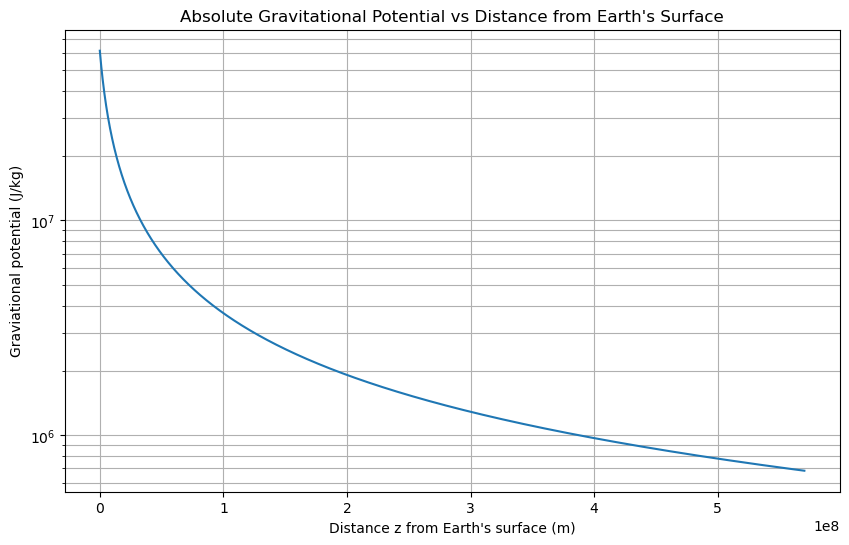

In [4]:
z = np.linspace(0, 1.5 * dEM, 2000) 
x = RE + z 
y = np.zeros_like(x) 

P1D = np.abs(P(ME, 0.0, 0.0, x, y)) 
p = plt 

p.figure(figsize=(10, 6))
p.plot(z, P1D)
p.yscale("log") 
p.xlabel("Distance z from Earth's surface (m)") 
p.ylabel("Graviational potential (J/kg)") 
p.title("Absolute Gravitational Potential vs Distance from Earth's Surface") 
p.grid(True, which="both") 

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

\\?\C:\Users\votgm\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


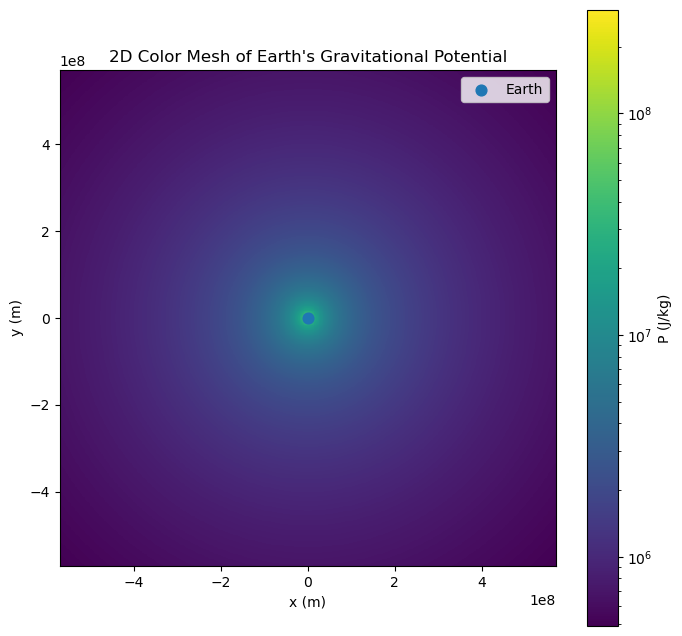

In [5]:
x = np.linspace(-1.5 * dEM, 1.5 * dEM, 600)
y = np.linspace(-1.5 * dEM, 1.5 * dEM, 600) 
X, Y = np.meshgrid(x, y) 

PE = P(ME, 0.0, 0.0, X, Y) 
absPE = np.abs(PE) 

vmin = np.nanmin(absPE[absPE > 0]) 
vmax = np.nanmax(absPE)

p = plt 
p.figure(figsize=(8, 8)) 
pcm = p.pcolormesh(X, Y, absPE, shading="auto", norm=LogNorm(vmin=vmin, vmax=vmax)) 

p.colorbar(pcm, label="P (J/kg)") 
p.scatter(0, 0, s=60, marker="o", label="Earth") 
p.xlabel("x (m)") 
p.ylabel("y (m)") 
p.title("2D Color Mesh of Earth's Gravitational Potential") 
p.gca().set_aspect("equal") 
p.legend()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

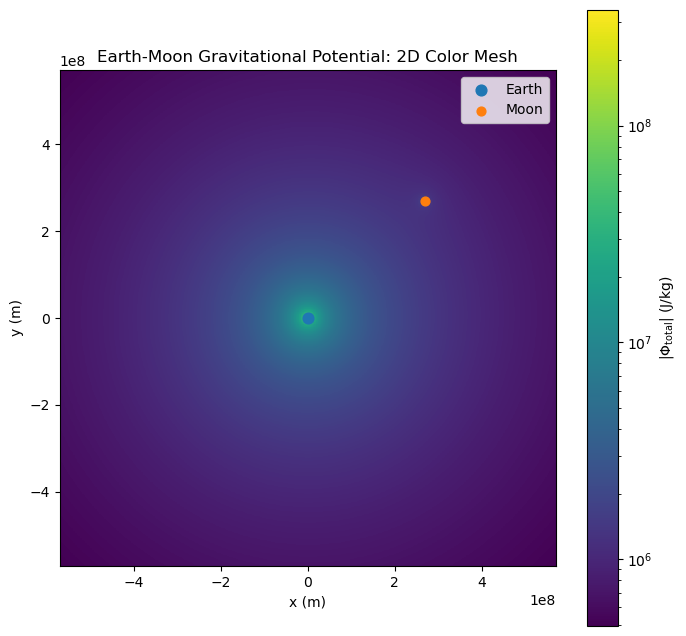

In [6]:
Xm = dEM / np.sqrt(2)
Ym = dEM / np.sqrt(2)

x = np.linspace(-1.5 * dEM, 1.5 * dEM, 700)
y = np.linspace(-1.5 * dEM, 1.5 * dEM, 700)
X, Y = np.meshgrid(x, y)

PE = P(ME, 0.0, 0.0, X, Y)
PM = P(MM, Xm, Ym, X, Y)
PT = PE + PM

absPT = np.abs(PT)

vmin = np.nanmin(absPT[absPT > 0])
vmax = np.nanmax(absPT)
p = plt

p.figure(figsize=(8, 8))
pcm = p.pcolormesh(X, Y, absPT, shading="auto", norm=LogNorm(vmin=vmin, vmax=vmax))
p.colorbar(pcm, label=r"$|\Phi_{\mathrm{total}}|$ (J/kg)")
p.scatter(0, 0, s=60, marker="o", label="Earth")
p.scatter(Xm, Ym, s=40, marker="o", label="Moon")
p.xlabel("x (m)")
p.ylabel("y (m)")
p.title("Earth-Moon Gravitational Potential: 2D Color Mesh")
p.gca().set_aspect("equal")
p.legend()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

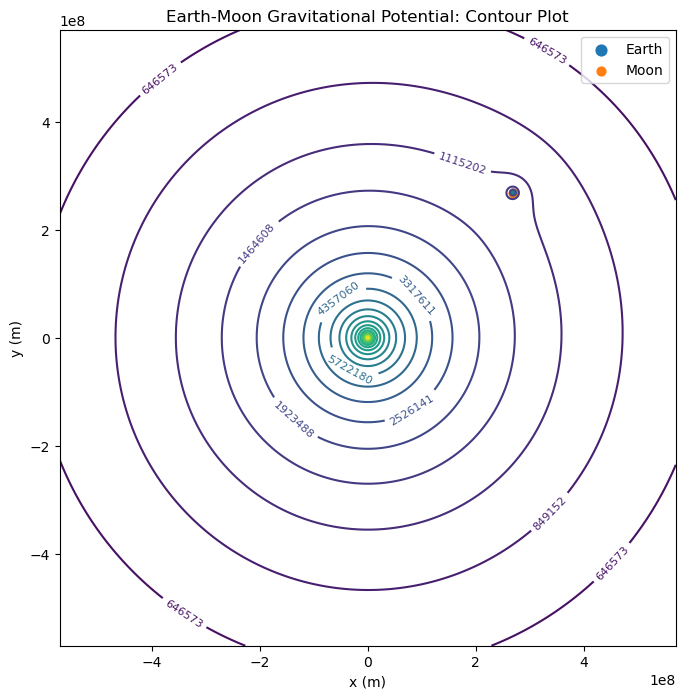

In [7]:
levels = np.logspace(np.log10(np.nanmin(absPT[absPT > 0])), np.log10(np.nanmax(absPT)), 25)
p = plt

p.figure(figsize=(8, 8))
cs = p.contour(X, Y, absPT, levels=levels, norm=LogNorm())
p.clabel(cs, inline=True, fontsize=8)
p.scatter(0, 0, s=60, marker="o", label="Earth")
p.scatter(Xm, Ym, s=40, marker="o", label="Moon")
p.xlabel("x (m)")
p.ylabel("y (m)")
p.title("Earth-Moon Gravitational Potential: Contour Plot")
p.gca().set_aspect("equal")
p.legend()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def F(M1, m2, x1, y1, x2, y2): 
    """
    Returns gravitational force components (Fx, Fy) experienced by the mass m2 from the force exerted by M1.

    Parameters
    ---------- 
    Mass M1 & m2: int or float 
    Location of M1 (x1, y1): int or float 
    Location of m2 (x2, y2): int, float, or np.ndarray

    Returns
    ------- 
    Returns two floats Fx and Fy 
    """ 
    if not all(isinstance(v,(int,float)) for v in [M1,m2,x1,y1]):
        raise TypeError("invalid input type")

    if not isinstance(x2,(int,float,np.ndarray)):
        raise TypeError("invalid input type")

    if not isinstance(y2,(int,float,np.ndarray)):
        raise TypeError("invalid input type")

    r = np.sqrt((x1-x2)**2 + (y1-y2)**2)
    r = np.where(r == 0, np.nan, r)

    rx = (x2 - x1) / r
    ry = (y2 - y1) / r

    Fx = -G * M1 * m2 * rx / (r**2)
    Fy = -G * M1 * m2 * ry / (r**2)

    return Fx, Fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

x1d: (250,)
y1d: (250,)
FxT: (250, 250)
FyT: (250, 250)


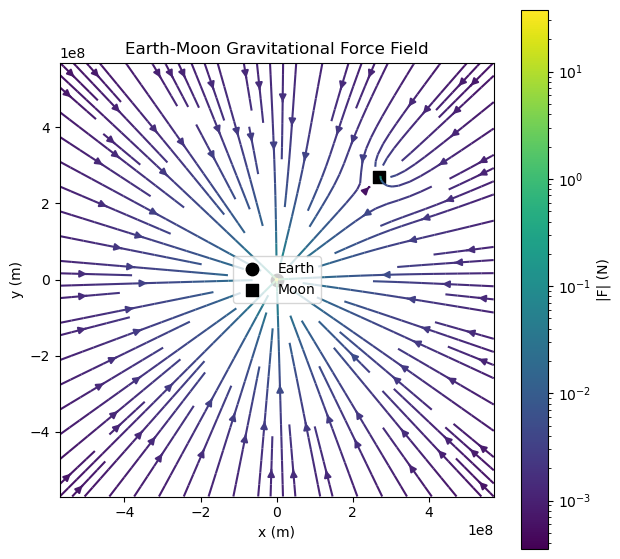

In [9]:
Xm = dEM / np.sqrt(2)
Ym = dEM / np.sqrt(2)
m_cmd = 1.0

x1d = np.linspace(-1.5 * dEM, 1.5 * dEM, 250)
y1d = np.linspace(-1.5 * dEM, 1.5 * dEM, 250)
X, Y = np.meshgrid(x1d, y1d)

FxE, FyE = F(ME, m_cmd, 0.0, 0.0, X, Y)
FxM, FyM = F(MM, m_cmd, Xm, Ym, X, Y)

FxT = FxE + FxM
FyT = FyE + FyM
FT = np.sqrt(FxT**2 + FyT**2)

print("x1d:", x1d.shape)
print("y1d:", y1d.shape)
print("FxT:", FxT.shape)
print("FyT:", FyT.shape)

plt.figure(figsize=(7, 7))
strm = plt.streamplot(
    x1d, y1d, FxT, FyT,
    color=FT,
    cmap="viridis",
    norm=LogNorm(vmin=np.nanmin(FT[FT > 0]), vmax=np.nanmax(FT)),
    density=1.2
)

plt.scatter(0, 0, c="black", s=80, marker="o", label="Earth")
plt.scatter(Xm, Ym, c="black", s=80, marker="s", label="Moon")
plt.colorbar(strm.lines, label="|F| (N)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Earth-Moon Gravitational Force Field")
plt.gca().set_aspect("equal")
plt.legend()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

We set the magnitudes of the Earth's and Moon's gravitational forces equal at the balance point:

$$
\left|\vec{F}_{\text{moon}}\right| = \left|\vec{F}_{\text{earth}}\right|
$$

Using Newton's law of gravitation,

$$
\frac{G M_E m}{r_E^2} = \frac{G M_M m}{r_M^2}
$$

Cancel \(G\) and the test mass \(m\):

$$
\frac{M_E}{r_E^2} = \frac{M_M}{r_M^2}
$$

Take square roots:

$$
\frac{\sqrt{M_E}}{r_E} = \frac{\sqrt{M_M}}{r_M}
$$

So,

$$
r_M = r_E \sqrt{\frac{M_M}{M_E}}
$$

The balance point lies on the line joining the Earth and Moon, so

$$
r_E + r_M = d_{EM}
$$

Substitute for \(r_M\):

$$
r_E + r_E \sqrt{\frac{M_M}{M_E}} = d_{EM}
$$

Factor out \(r_E\):

$$
r_E \left(1 + \sqrt{\frac{M_M}{M_E}}\right) = d_{EM}
$$

Therefore,

$$
r_E = \frac{d_{EM}}{1 + \sqrt{\frac{M_M}{M_E}}}
$$

and

$$
r_M = d_{EM} - r_E
$$

Since the Moon is located at

$$
(x_M, y_M) = \left(\frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}}\right),
$$

the balance point is the same fraction of the way from Earth to Moon along that line:

$$
x_B = \frac{r_E}{d_{EM}} x_M, \qquad y_B = \frac{r_E}{d_{EM}} y_M
$$

And your updated plot, including the balance point, goes in the cell below.

Distance from Earth to balance point (m): 341845360.5585487
Distance from Moon to balance point (m): 38154639.44145131
Balance point coordinates (m): (np.float64(241721172.5681101), np.float64(241721172.5681101))


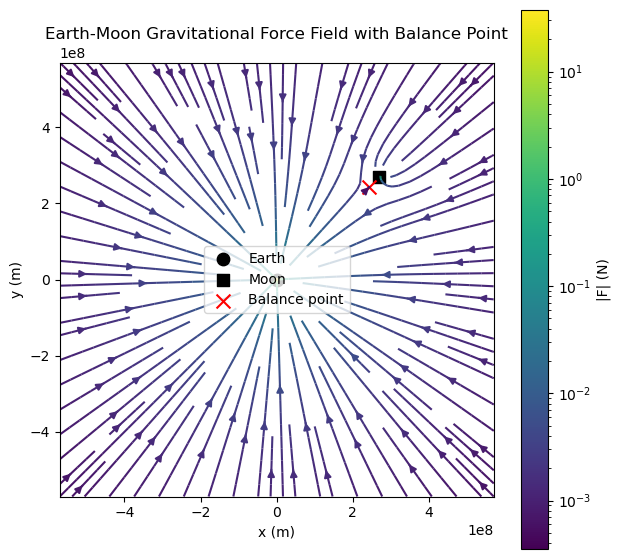

In [10]:
rE = dEM / (1 + np.sqrt(MM / ME))
rM = dEM - rE

xB = (rE / dEM) * Xm
yB = (rE / dEM) * Ym

print("Distance from Earth to balance point (m):", rE)
print("Distance from Moon to balance point (m):", rM)
print("Balance point coordinates (m):", (xB, yB))

plt.figure(figsize=(7, 7))
strm = plt.streamplot(
    X, Y, FxT, FyT,
    color=FT,
    cmap="viridis",
    norm=LogNorm(vmin=np.nanmin(FT[FT > 0]), vmax=np.nanmax(FT)),
    density=1.2
)

plt.scatter(0, 0, c="black", s=80, marker="o", label="Earth")
plt.scatter(Xm, Ym, c="black", s=80, marker="s", label="Moon")
plt.scatter(xB, yB, c="red", s=100, marker="x", label="Balance point")

plt.colorbar(strm.lines, label="|F| (N)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Earth-Moon Gravitational Force Field with Balance Point")
plt.gca().set_aspect("equal")
plt.legend()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is much closer to the Moon than to the Earth.

Numerically, the distance from the Earth to the balance point is

$$
r_E = \frac{d_{EM}}{1 + \sqrt{M_M/M_E}},
$$

which is most of the Earth-Moon distance, while the distance from the Moon is only

$$
r_M = d_{EM} - r_E.
$$

This makes sense because the Earth is much more massive than the Moon. Since gravitational force scales like

$$
F \propto \frac{M}{r^2},
$$

the weaker pull of the Moon can only match the Earth's pull if the balance point is much nearer to the Moon. In other words, you must get much closer to the smaller mass before its gravity becomes comparable to that of the larger mass.

So the result is physically reasonable: the balance point should lie between the Earth and Moon, but noticeably closer to the Moon.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [16]:
m0 = 2.8 * 10**6 # kg 
mf = 1.19 * 10**5 # kg 
m = 1.5 * 10**4 # kg/s 
T = (m0 - mf)/m # s     
print(T)

178.73333333333332


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [31]:
ve = 4.0 * 10**3 # m/s
m = 1.5 * 10**4 # kg/s 

def V(t):
    """
    Returns the change in velocity of a rocket

    Parameters
    ----------
    Time t: int or float 
    
    Wet mass m0: int or float 
    Dry mass mf: int or float 
    Burn rate m: int or float 
    Exhaust speed ve: int or float 
    Gravitational constant g: int or float 

    Returns
    -------
    Returns type float 
    """
    m = 1.5 * 10**4 # kg/s 
    if not all(isinstance(v, (int, float)) for v in [t, m0, mf, m, ve, G]):
        raise TypeError("invalid input type")
    if t < 0:
        raise ValueError("time must be nonnegative")
    if m <= 0:
        raise ValueError("burn rate must be positive")
    if m0 <= mf:
        raise ValueError("wet mass must be greater than dry mass")
    if mf <= 0 or m0 <= 0:
        raise ValueError("masses must be positive")
    T = (m0 - mf) / m
    if t > T:
        return 0.0
    m = m0 - m * t
    if m <= 0:
        raise ValueError("rocket mass must remain positive")
    return ve * np.log(m0 / m) - G * t

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [32]:
hresult, herror = integrate.quad(V, 0, T)
hresult 

614711.4951554254

4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

Our calculation gives a burn time of about

$$
T \approx 178.7 \text{ s}
$$

and a burnout altitude of about

$$
h \approx 6.15 \times 10^5 \text{ m} = 615 \text{ km}.
$$

Compared with the reported test data of about \(160\text{ s}\) burn time and \(70\text{ km}\) altitude, the model **overestimates both the burn time and the altitude**.

The burn time is somewhat close, but still a bit too large. This likely happens because the model assumes a perfectly constant burn rate and uses simplified mass values. In reality, the first-stage burn is not perfectly ideal, and the exact wet mass, dry mass, and propellant flow rate may differ from the simplified values used here.

The altitude is overestimated by a much larger amount. This makes sense because the model is highly idealized. It ignores several important real-world effects:

1. **Air drag**: The rocket loses a large amount of energy pushing through the atmosphere, especially early in flight. Ignoring drag makes the rocket rise much higher in the model than it does in reality.

2. **Gravity losses during a real trajectory**: Although the model includes a \(-gt\) term in the velocity, it still assumes a very simplified vertical motion. Real launches do not go perfectly straight up for the entire burn, and part of the thrust is effectively used to shape the trajectory rather than maximize altitude.

3. **Changing gravity with altitude**: We treated \(g\) as constant, which is a simplification. While this is not the biggest source of error, it still affects the result.

4. **Stage and vehicle simplifications**: The Saturn V is a multistage rocket, and the real first-stage test conditions are more complicated than a single ideal rocket-equation model.

Overall, the calculation gives the right general idea, but it is an **idealized overestimate**, especially for the altitude. The biggest reason is that the model neglects atmospheric drag and other real launch losses.